# Library

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))

import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
import torch
import pytorch_lightning as pl
import torch.nn as nn
import wandb
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import DatasetFolder
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from torch.utils.data import random_split, Subset
import gc
from sklearn.utils.class_weight import compute_class_weight

from simdinov2.models.return_models import get_dino_finetuned_downloaded

/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/swiglu_ffn.py:43: UserWarning: Using xFormers (SwiGLU)
  warnings.warn("Using xFormers (SwiGLU)")
/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/attention.py:27: UserWarning: Using xFormers (Attention)
  warnings.warn("Using xFormers (Attention)")
/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/attention.py:38: UserWarning: Using SDPA Attention
  warnings.warn("Using SDPA Attention")
/media/new_volumn/SIMDINOV2_EASYRICE/simdinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


# Loading data

In [2]:
saved_dir = "AllPNG_Paddy25-03-2024-6Class"

train = np.load(f"{saved_dir}/train_data.npz")
valid = np.load(f"{saved_dir}/val_data.npz")
test  = np.load(f"{saved_dir}/test_data.npz")

In [3]:
x_train = train['x_train']
y_train_keys = train['y_train']

x_valid = valid['x_val'] 
y_valid_keys = valid['y_val']

x_test = test['x_test']
y_test_keys = test['y_test']

In [4]:
np.unique(y_train_keys)

array(['PB1 Basmati', 'Pusa', 'Pusa 1121 Basmati', 'Pusa 1401 Basmati',
       'Pusa 1509 Basmati', 'Pusa 1718 Basmati', 'Sharbati Rice',
       'Sugandha Basmati', 'TAJ'], dtype='<U17')

In [5]:
Counter(y_train_keys)

Counter({np.str_('Pusa 1509 Basmati'): 17540,
         np.str_('Pusa 1718 Basmati'): 17428,
         np.str_('Pusa 1121 Basmati'): 17129,
         np.str_('Pusa 1401 Basmati'): 16369,
         np.str_('Sugandha Basmati'): 15262,
         np.str_('PB1 Basmati'): 4920,
         np.str_('Sharbati Rice'): 4619,
         np.str_('Pusa'): 4447,
         np.str_('TAJ'): 4363})

In [6]:
# Transform labels to a trinary classification problem
def transform_breed(breed):
    return "Other" if breed not in ["Pusa 1509 Basmati", "Pusa 1121 Basmati", "Pusa 1718 Basmati", "Pusa 1401 Basmati", "Sugandha Basmati"] else breed
y_train = np.array([transform_breed(key) for key in y_train_keys])
y_valid = np.array([transform_breed(key) for key in y_valid_keys])
y_test = np.array([transform_breed(key) for key in y_test_keys ])

In [7]:
Counter(y_train), Counter(y_valid), Counter(y_test)

(Counter({np.str_('Other'): 18349,
          np.str_('Pusa 1509 Basmati'): 17540,
          np.str_('Pusa 1718 Basmati'): 17428,
          np.str_('Pusa 1121 Basmati'): 17129,
          np.str_('Pusa 1401 Basmati'): 16369,
          np.str_('Sugandha Basmati'): 15262}),
 Counter({np.str_('Other'): 4460,
          np.str_('Pusa 1121 Basmati'): 4029,
          np.str_('Pusa 1401 Basmati'): 4023,
          np.str_('Pusa 1718 Basmati'): 4016,
          np.str_('Pusa 1509 Basmati'): 3995,
          np.str_('Sugandha Basmati'): 2930}),
 Counter({np.str_('Pusa 1401 Basmati'): 4758,
          np.str_('Pusa 1121 Basmati'): 3988,
          np.str_('Sugandha Basmati'): 3843,
          np.str_('Pusa 1509 Basmati'): 3649,
          np.str_('Pusa 1718 Basmati'): 3611,
          np.str_('Other'): 3233}))

In [8]:
# Encode labels using Keras utilities
unique_classes = np.unique(y_train) # extract distinct classes
class_indices = {label: index for index, label in enumerate(unique_classes)} # class with index
y_train_encoded = np.array([class_indices[label] for label in y_train]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]
y_valid_encoded = np.array([class_indices[label] for label in y_valid]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]
y_test_encoded = np.array([class_indices[label] for label in y_test]) # [0, 1, 2, 3, 0, 1, 2, 3, ...]

# Calculate class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = {index: weight for index, weight in enumerate(class_weights)}

In [9]:
class_indices

{np.str_('Other'): 0,
 np.str_('Pusa 1121 Basmati'): 1,
 np.str_('Pusa 1401 Basmati'): 2,
 np.str_('Pusa 1509 Basmati'): 3,
 np.str_('Pusa 1718 Basmati'): 4,
 np.str_('Sugandha Basmati'): 5}

In [10]:
intensity_ranges = {
        "brightness": np.linspace(0.9, 1.1, 5),  # Range should be >0
        "contrast": np.linspace(0.9, 1.1, 5),
        "saturation": np.linspace(0.9, 1.1, 5),  # Ensure positive values
        "hue": np.linspace(-0.05, 0.05, 5)  # Hue range should be (-0.5, 0.5)
        }

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # Resize the image
#     # transforms.RandomApply(
#     # [transforms.ColorJitter(brightness=(intensity_ranges["brightness"].min(), intensity_ranges["brightness"].max()),
#     #                         contrast=(intensity_ranges["contrast"].min(), intensity_ranges["contrast"].max()),
#     #                         saturation=(intensity_ranges["saturation"].min(), intensity_ranges["saturation"].max()),
#     #                         hue=(intensity_ranges["hue"].min(), intensity_ranges["hue"].max()))],
#     #                         p=0.8,),
#     # transforms.ToTensor(),  # Convert image to tensor
#     torch.tensor(dtype=torch.float32).permute(2, 0, 1) / 255.0,
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalize image
# ])

# Transform if needed (example: normalize and convert to tensor)
class CustomTransform:
    def __call__(self, image):
        # Custom transformation logic here (e.g., normalize, augment, etc.)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return image

In [11]:
class CustomDataset(Dataset):
    def __init__(self, x_data, y_data, transform=None):
        self.x_data = x_data  # NumPy array of images embeddings
        self.y_data = y_data  # NumPy array of labels
        self.transform = transform

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):

        img = self.x_data[idx]   
        if self.transform:
            img = self.transform(img)    
        label = self.y_data[idx]  # Get corresponding label

        return img, torch.tensor(label, dtype=torch.long)

In [12]:
transform = CustomTransform()
train_dataset = CustomDataset(x_train, y_train_encoded, transform)
valid_dataset = CustomDataset(x_valid, y_valid_encoded, transform)
test_dataset = CustomDataset(x_test, y_test_encoded, transform)

In [13]:
train_dataset[0][1].shape

torch.Size([])

In [14]:
y_train_encoded.shape

(102077,)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(valid_dataset, batch_size=64,num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64,num_workers=4)

In [16]:
for x, y in train_loader:
    print(x.shape, y.shape)
    # print(y)
    break

torch.Size([64, 3, 224, 224]) torch.Size([64])


# Model initializing

In [21]:
class Classifier(pl.LightningModule):
    def __init__(self, num_classes=3, class_weights=None):
        super(Classifier, self).__init__()
        self.base_model = models.densenet121(pretrained=True)
        self.base_model.classifier = nn.Sequential(
                                    nn.Linear(self.base_model.classifier.in_features, 128),
                                    nn.ReLU(),
                                    nn.Dropout(0.5),
                                    nn.Linear(128, 64),
                                    nn.ReLU(),
                                    nn.BatchNorm1d(64),
                                    nn.Dropout(0.5),
                                    nn.Linear(64, num_classes),
                                    nn.Softmax(dim=1)
                    )
        self.model = self.base_model
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.base_model(x)

    def training_step(self, batch, batch_idx):
        self.criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to("cuda")) if class_weights is not None else nn.CrossEntropyLoss()
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        
        # Get predicted labels (taking the class with the highest probability)
        preds = torch.argmax(y_hat, dim=1)
    
        # Calculate accuracy: Number of correct predictions / Total number of predictions
        correct = (preds == y).sum().item()
        accuracy = correct / y.size(0)  # Divide by batch size to get accuracy

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", accuracy, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        acc = (torch.argmax(y_hat, dim=1) == y).float().mean()
        self.log('val_loss', loss)
        self.log('val_acc', acc)

    def configure_optimizers(self):
        if (self.current_epoch // 3) % 2 == 0:  # Freeze parameters for 3 epochs
            for param in self.model.features.parameters():
                param.requires_grad = False
            optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.model.parameters()), lr=1e-3)
            self.print("Freezing parameters for 3 epochs")
        else:  # Unfreeze parameters for the next 3 epochs
            for param in self.model.features.parameters():
                param.requires_grad = True
            optimizer = optim.Adam(self.parameters(), lr=1e-4)
            self.print("Unfreezing parameters for 3 epochs")
            
        return optimizer

# Model training

In [22]:
dirpath = "checkpoints/3April/"
os.makedirs(dirpath, exist_ok=True)
filename = "best_model_7class_3AprilCNN"

In [23]:
model = Classifier(num_classes=len(class_indices), class_weights=torch.tensor(class_weights, dtype=torch.float32))


/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:

# Define the checkpoint callback
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',         # Monitor validation accuracy
    dirpath=dirpath,    # Directory to save the checkpoints
    filename=filename,     # Filename for the best model
    save_top_k=1,              # Save only the best model
    mode='max',                # We want the maximum validation accuracy
)
early_stop_callback = EarlyStopping(monitor="val_acc", min_delta=0.00, patience=10, verbose=False, mode="max")


# Trainer setup
trainer = pl.Trainer(max_epochs=100, 
                     accelerator="gpu" if torch.cuda.is_available() else "mps",
                     callbacks=[checkpoint_callback, early_stop_callback])

trainer.fit(model, train_loader, val_loader)

In [ ]:
wandb.finish()

# Evaluation

In [73]:
def predict_and_transform(model, val_loader):
    
    predictions = []
    

    # Disable gradient computation for inference
    model.to("cuda")
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            x_batch = batch[0].to("cuda")
            x_batch = x_batch.squeeze(1)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1)  # Get the predicted class index for each sample
            predictions.extend(preds.cpu().numpy())  # Move back to CPU and store the predictions

    predicted_classes = np.array(predictions)

    
    return predicted_classes

In [74]:
dirpath, filename

('checkpoints/3April/', 'best_model_trinary_3AprilCNN')

In [81]:
classifier_model = Classifier.load_from_checkpoint(f"{dirpath}/{filename}.ckpt", strict=False)
predicted_classes = predict_and_transform(classifier_model, test_loader)

del classifier_model # Delete the model to free up memory
gc.collect()
torch.cuda.empty_cache()

/home/easyrice/anaconda3/envs/torch/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['criterion.weight']


In [82]:
import seaborn as sns

In [89]:
def plot_confusion_matrix_percentage(y_true, y_pred, class_labels):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_labels)))
    cm_percentage = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  # Convert to percentage
    cm_percentage = np.nan_to_num(cm_percentage)  # Handle division by zero
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Percentage)->Denset121')
    plt.show()

In [90]:
class_indices

{np.str_('Other'): 0,
 np.str_('PUSA_PADDY-1509_HARYANA_3-7-24'): 1,
 np.str_('PUSA_PADDY_1121_HARYANA_8-7-2024'): 2}

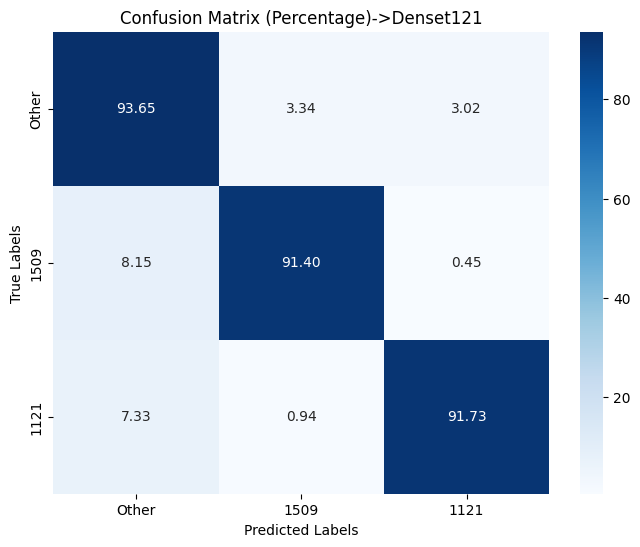

In [91]:
plot_confusion_matrix_percentage(y_test_encoded, predicted_classes, ['Other', '1509', '1121'])

In [92]:
y_test_keys

array(['PUSA_1718', 'PUSA_1718', 'PUSA_1718', ...,
       'PUSA_PADDY_1121_HARYANA_8-7-2024',
       'PUSA_PADDY_1121_HARYANA_8-7-2024',
       'PUSA_PADDY_1121_HARYANA_8-7-2024'], dtype='<U32')

In [93]:
class_indices

{np.str_('Other'): 0,
 np.str_('PUSA_PADDY-1509_HARYANA_3-7-24'): 1,
 np.str_('PUSA_PADDY_1121_HARYANA_8-7-2024'): 2}

In [94]:
import pandas as pd

idx_to_class = {v: k for k, v in class_indices.items()}
# Convert predicted class indices to actual class names
predicted_class_names = np.array([idx_to_class[idx] for idx in predicted_classes])
df = pd.DataFrame({'key_image_name': y_test_keys, 'prediction': predicted_class_names})

# Group by key_image_name and count prediction occurrences
result = df.groupby(['key_image_name', 'prediction']).size().unstack(fill_value=0)

In [95]:
result

prediction,Other,PUSA_PADDY-1509_HARYANA_3-7-24,PUSA_PADDY_1121_HARYANA_8-7-2024
key_image_name,,,
PUSA HARYANA,783,13,7
PUSA_1718,457,26,76
PUSA_PADDY-1509_HARYANA_3-7-24,146,1637,8
PUSA_PADDY_1121_HARYANA_8-7-2024,140,18,1753
PUSA_PADDY_1401_HARYANA 3-7-24,710,12,12
PUSA_SHARBATI,722,3,6
PUSA_SUGANDHA_HARYANA 3-7-24,585,62,4


In [97]:
result.to_csv("CNN3AprilTrinary.csv")